# Netective Properties Dataframe

### Imports

In [1]:
import pandas as pd
from netective.structure import properties
import inspect
import networkx as nx
from freyrelab.nets.paths2 import ShortestPaths, Efficiency, ShortestDistances
from freyrelab.regnets.regnet import RegNet
import numpy as np
import seaborn as sb

### Fxns auxiliares

In [4]:
def remove_self_loops(G: nx.DiGraph):
    print(type(G))
    G.remove_edges_from(nx.selfloop_edges(G))

def normalize_props(total_instances, G, norm=None):
    norm_scalar_values = {}
    norm_dist_values = {}
    for name, x in total_instances.items():
        dict_ = (
            norm_scalar_values
            if x._return_type == "scalar"
            else norm_dist_values
        )
        try:
            if norm == "network":
                dict_[name] = x.norm_network()
            elif norm == "biological":
                dict_[name] = x.norm_biol()
        except (NotImplementedError, properties.NormalizationError):
            dict_[name] = np.nan

    return norm_scalar_values, norm_dist_values

### Obtención de objetos properties

In [2]:
parent_class = properties._Property

In [6]:
def get_child_classes(parent_class):
    child_classes = []
    for name, obj in inspect.getmembers(properties):
        if (
            inspect.isclass(obj)
            and issubclass(obj, parent_class)
            and obj != parent_class
        ):
            child_classes.append(obj)
    return child_classes

child_classes = get_child_classes(parent_class)

### Creación de Dataframe

#### Dummy network

In [7]:
G = RegNet()
n_nodes = 40
G.add_nodes_from(range(n_nodes))
G.add_edges_from([(i,j) for i in range(n_nodes) for j in range(n_nodes)])

#### Creación de instancias

In [9]:
def get_instances_no_paths(G, child_classes):
    instances = {x.__name__: x(G) for x in child_classes if not x._use_paths}
    return instances

def get_instances_paths(G, child_classes, net_shortest_paths, net_shortest_distances):
    instances = {x.__name__: x(G, net_shortest_paths = net_shortest_paths, net_shortest_distances = net_shortest_distances) for x in child_classes if x._use_paths}
    return instances

In [10]:
# Properties that do not use paths object
instances = get_instances_no_paths(G, child_classes)
    
# Objetos paths
remove_self_loops(G)
G = G.giant_component
G = G.to_undirected()
net_shortest_paths = ShortestPaths(G)
net_shortest_distances = ShortestDistances(G)
    
# Properties that use paths object
# They use the giant component from an undirected graph with no selfloops
instances_paths = get_instances_paths(G, child_classes, net_shortest_paths, net_shortest_distances)

<class 'freyrelab.regnets.regnet.RegNet'>


In [11]:
instances.update(instances_paths)

In [12]:
instances

{'AverageClusteringCoefficient': <netective.structure.properties.AverageClusteringCoefficient at 0x213a79baf70>,
 'AverageDegreeNearestNeighbors': <netective.structure.properties.AverageDegreeNearestNeighbors at 0x213a7baa820>,
 'AverageOutDegreeNearestNeighbors': <netective.structure.properties.AverageOutDegreeNearestNeighbors at 0x213a7baab20>,
 'ClusteringCoefficient': <netective.structure.properties.ClusteringCoefficient at 0x213a7baa790>,
 'ComplexFeedForwardCircuits': <netective.structure.properties.ComplexFeedForwardCircuits at 0x213a7baa730>,
 'Density': <netective.structure.properties.Density at 0x213a7baac70>,
 'EntropyPKout': <netective.structure.properties.EntropyPKout at 0x213a7baa9d0>,
 'FeedbackLoops_3': <netective.structure.properties.FeedbackLoops_3 at 0x213a7baa7f0>,
 'GenesintheGiantComponent': <netective.structure.properties.GenesintheGiantComponent at 0x213a7baa6d0>,
 'GiniIndex': <netective.structure.properties.GiniIndex at 0x213a7baadc0>,
 'InDegree': <netective.

#### Diccionario

In [13]:
#   - @use_direction
#   - @use_selfloops
#   - @use_giant_component
#   - @use_paths
#   - @return_scalar
#   - @return_distribution
properties_info = {

    'Name' : [],
    'Selfloops' : [],
    'Directed networks' : [], 
    'Giant component' : [],
    'Uses object paths' : [],
    'Return scalar' : [],
    'Return a distribution' : []
}

In [14]:
for object in instances.values():
    properties_info['Name'].append(object.CLASS_NAME)
    properties_info['Selfloops'].append(object._use_selfloops)
    properties_info['Directed networks'].append(object._use_direction)
    properties_info['Giant component'].append(object._use_giant_component)
    properties_info['Uses object paths'].append(object._use_paths)
    if object._return_type == 'scalar':
        properties_info['Return scalar'].append(True)
        properties_info['Return a distribution'].append(False)
    else:
        properties_info['Return scalar'].append(False)
        properties_info['Return a distribution'].append(True)

### Dataframe completo

In [17]:
properties_df = pd.DataFrame.from_dict(properties_info)
properties_df

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
0,Average Clustering Coefficient,False,False,False,False,True,False
1,Average Degree for Nearest Neighbors (Undirected),False,False,False,False,False,True
2,Average Degree for Nearest Neighbors (Out-Out),False,True,False,False,False,True
3,Clustering Coefficient,False,False,False,False,False,True
4,Complex Feed-Forward Circuits,False,True,False,False,True,False
5,Density,True,True,True,False,True,False
6,Entropy of Degree Distribution,True,True,False,False,True,False
7,3-Feedback Loops,False,True,False,False,True,False
8,Gene % in the Giant Component,False,False,True,False,True,False
9,Gini Index,True,True,False,False,True,False


### Propiedades que reciben redes sin modificaciones

In [6]:
foo = np.asarray([True, True, False])
faa = np.asarray([True, True, True])
np.array_equal(foo,faa)

False

In [42]:
mask = (properties_df['Selfloops']) & (properties_df['Directed networks']) & (properties_df['Giant component'] == False) & (properties_df['Uses object paths'] == False)
complete_net = properties_df.loc[mask]
complete_net


,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
6,Entropy of Degree Distribution,True,True,False,False,True,False
9,Gini Index,True,True,False,False,True,False
10,In-Degree,True,True,False,False,False,True
12,Max In-Dregree,True,True,False,False,True,False
13,Max Out-Degree,True,True,False,False,True,False
14,Out-Degree,True,True,False,False,False,True
15,Regulators,True,True,False,False,True,False
17,Self-Regulations,True,True,False,False,True,False


### Propiedades que reciben redes dirigidas PERO no admiten self loops

In [43]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks']) & (properties_df['Giant component'] == False) & (properties_df['Uses object paths'] == False)
no_selfloops = properties_df.loc[mask]
no_selfloops

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
2,Average Degree for Nearest Neighbors (Out-Out),False,True,False,False,False,True
4,Complex Feed-Forward Circuits,False,True,False,False,True,False
7,3-Feedback Loops,False,True,False,False,True,False


### Propiedades que reciben redes SIN selfloops Y redes NO dirigidas

#### Tampoco usan objeto paths ni componente gigante

In [46]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks'] == False) & (properties_df['Giant component'] == False) & (properties_df['Uses object paths'] == False)
undirected = properties_df.loc[mask]
undirected

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
0,Average Clustering Coefficient,False,False,False,False,True,False
1,Average Degree for Nearest Neighbors (Undirected),False,False,False,False,False,True
3,Clustering Coefficient,False,False,False,False,False,True
16,Rich Club Coefficient,False,False,False,False,False,True


### Propiedades que ocupan componente gigante
#### No usa objetos paths

In [52]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks'] == False) & (properties_df['Giant component'] == True) & (properties_df['Uses object paths'] == False)
giant = properties_df.loc[mask]
giant

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
8,Gene % in the Giant Component,False,False,True,False,True,False


### Propiedades que ocupan componente gigante Y objeto paths

In [53]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks'] == False) & (properties_df['Giant component'] == True) & (properties_df['Uses object paths'] == True)
paths = properties_df.loc[mask]
paths

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Return scalar,Return a distribution
19,Average Local Efficiency,False,False,True,True,True,False
20,Average Shortest Path Length,False,False,True,True,True,False
21,Betweenness Centrality,False,False,True,True,False,True
22,Center,False,False,True,True,True,False
23,Diameter,False,False,True,True,True,False
24,Eccentricity,False,False,True,True,False,True
25,Global Efficiency,False,False,True,True,True,False
26,Periphery,False,False,True,True,True,False
27,Radius,False,False,True,True,True,False


### Creación heatmap

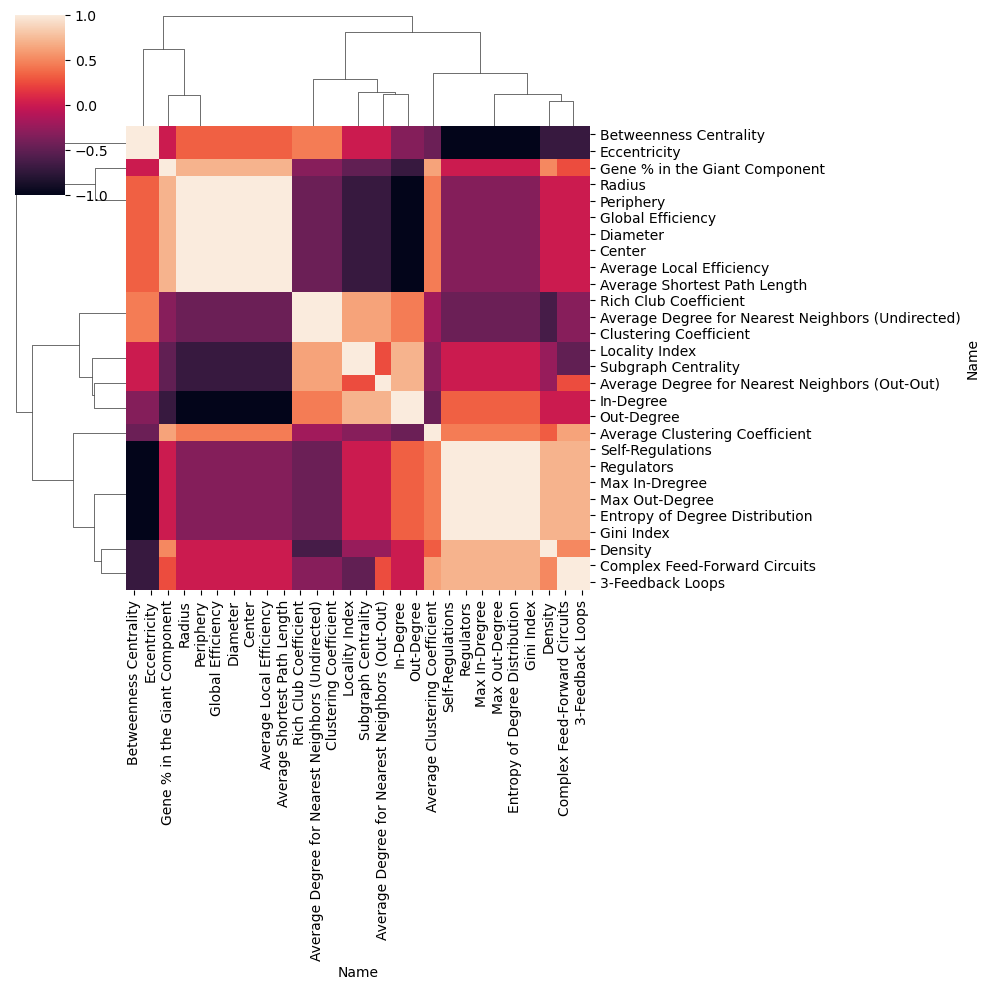

In [48]:
heatmap_df = properties_df.replace(False, 0)
heatmap_df = heatmap_df.replace(True, 1)
heatmap_df = heatmap_df.set_index('Name')
foo = heatmap_df.T
buena = foo.corr()
cluster = sb.clustermap(buena)

### Testing

In [2]:
from netective.structure.structure import get_child_classes, Structure, compare_networks, characterize_network

validate --- G has 100 nodes and 6903 edges.
validate RegNet --- G has 100 nodes and 4512 edges.
init --- graph_observer.graph_hash: None
hash: 5b2004cbf42dc92667d827dbeba41df20da0d78f
validate --- G has 100 nodes and 6903 edges.
validate RegNet --- G has 100 nodes and 4512 edges.
Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\utils.py:152: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skewness = skew(data, nan_policy="omit")
G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\utils.py:153: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(data, nan_policy="omit")


None
1:   {'Prueba': {'Entropy of Degree Distribution': 4.000016292194832, 'Gini Index': -0.4728789893617027, 'Max In-Dregree': 82, 'Max Out-Degree': 79, 'Regulators': 100, 'Self-Regulations': 0, 'Density': 0.4512, 'Complex Feed-Forward Circuits': 10751, '3-Feedback Loops': 109805, 'Average Clustering Coefficient': 0.9119895626630502, 'Gene % in the Giant Component': 100, 'Average Local Efficiency': 0.9559947813315252, 'Average Shortest Path Length': 1.0884848484848484, 'Center': 100, 'Diameter': 2, 'Global Efficiency': 0.9557575757575758, 'Periphery': 100, 'Radius': 2}}
2:   {'Prueba': {'In-Degree': (69.03, 23.40313131313131, 0.1349029183546498, -0.04117319788871887), 'Out-Degree': (69.03, 21.90818181818182, -0.5090811961187147, 0.9243974872850762), 'Locality Index': (0.8209555139530196, 0.002742884198863664, 0.08708850706499449, -0.546597074126419), 'Subgraph Centrality': (1.7244020778181675e+37, 1.3748921450178118e+72, 0.03195915897419015, -0.5614952596397256), 'Average Degree for N

G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\structure\structure.py:778: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_dist.show()
G:\Mi unidad\Respaldo\Genomicas\netective\src\netective\structure\structure.py:782: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_scalar.show()


{'Prueba': {'Entropy of Degree Distribution': 4.000016292194832, 'Gini Index': -0.4728789893617027, 'Max In-Dregree': 82, 'Max Out-Degree': 79, 'Regulators': 100, 'Self-Regulations': 0, 'Density': 0.4512, 'Complex Feed-Forward Circuits': 10751, '3-Feedback Loops': 109805, 'Average Clustering Coefficient': 0.9119895626630502, 'Gene % in the Giant Component': 100, 'Average Local Efficiency': 0.9559947813315252, 'Average Shortest Path Length': 1.0884848484848484, 'Center': 100, 'Diameter': 2, 'Global Efficiency': 0.9557575757575758, 'Periphery': 100, 'Radius': 2}}


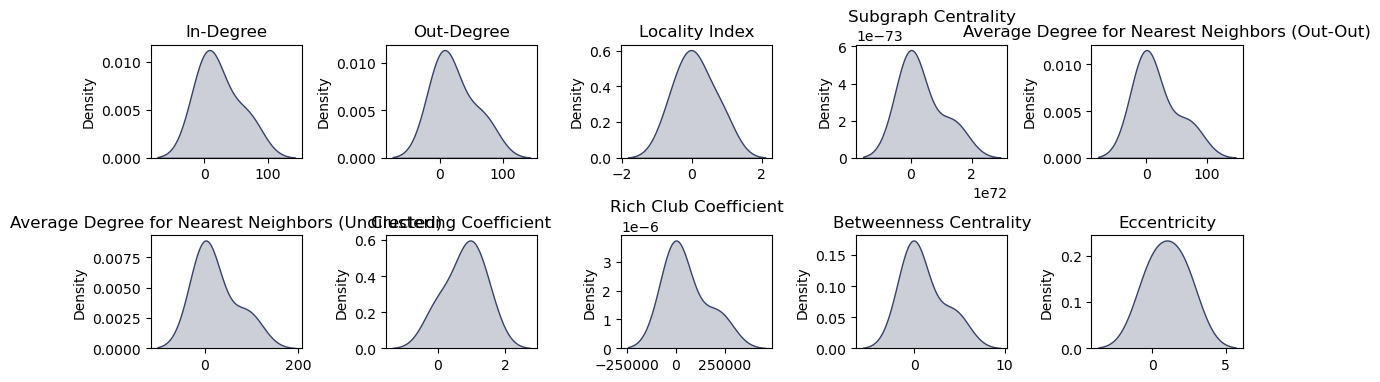

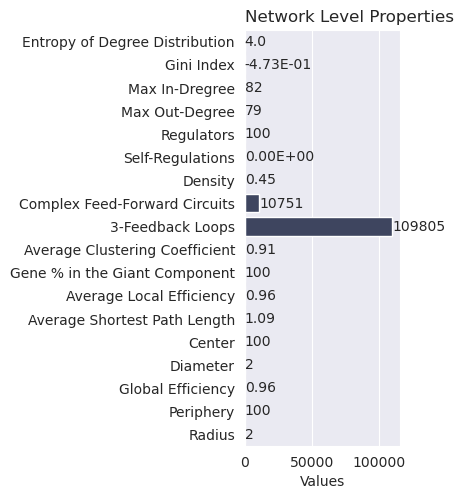

In [8]:
G = nx.erdos_renyi_graph(100, 0.7, directed=True)
characterize_network(G, name='Prueba')

In [3]:



G = nx.erdos_renyi_graph(100, 0.3, directed=True)
F = nx.erdos_renyi_graph(100, 0.6, directed=True)
A = nx.erdos_renyi_graph(100, 0.5, directed=True)
prueba = {
    'G' : G,
    'F' : F,
    'A' : A
}

scalar, dist = compare_networks(prueba)


Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



  0%|          | 0/7 [00:00<?, ?it/s]

Running G
Running F
Running A
Error: 'list' object has no attribute 'keys'
Error: 'list' object has no attribute 'keys'
Error: 'list' object has no attribute 'keys'


  0%|          | 0/7 [00:04<?, ?it/s]


{}


ValueError: Not enough data to compare.

In [6]:
parent_class = properties._Property
get_child_classes(parent_class, selected_props='all')

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



{netective.structure.properties.AverageClusteringCoefficient: array([False, False, False, False]),
 netective.structure.properties.AverageDegreeNearestNeighbors: array([False, False, False, False]),
 netective.structure.properties.AverageLocalEfficiency: array([False, False,  True,  True]),
 netective.structure.properties.AverageOutDegreeNearestNeighbors: array([False,  True, False, False]),
 netective.structure.properties.AverageShortestPathLength: array([False, False,  True,  True]),
 netective.structure.properties.BetweennessCentrality: array([False, False,  True,  True]),
 netective.structure.properties.Center: array([False, False,  True,  True]),
 netective.structure.properties.ClusteringCoefficient: array([False, False, False, False]),
 netective.structure.properties.ComplexFeedForwardCircuits: array([False,  True, False, False]),
 netective.structure.properties.Density: array([ True,  True,  True, False]),
 netective.structure.properties.Diameter: array([False, False,  True,  Tr